In [7]:
import ChessLens

import numpy as np
import torch
import cv2

import os

from tqdm import tqdm

from matplotlib import pyplot as plt
from Dataset.DataSetLoaders import ChessDataset

from Utils import ChessUtils

In [8]:
filename = "/mnt/C/CNN_Dataset/combi_chess.v1i.yolov11/train/images/1a8a4abcba7c4ead35c01f05b9fae8e5_jpg.rf.251f8fa7bc0b5c9d96957ad6be08816d.jpg"
labels_filename = "/mnt/C/CNN_Dataset/combi_chess.v1i.yolov11/train/labels/1a8a4abcba7c4ead35c01f05b9fae8e5_jpg.rf.251f8fa7bc0b5c9d96957ad6be08816d.txt"

In [3]:
img = ChessLens.ChessLensImage(filename, "cnn")
img.detect_board()

(tensor([[151.,  58.],
         [542.,  62.],
         [553., 580.],
         [ 64., 567.]]),
 np.float64(0.9162500240412167))

In [4]:
img.board_detection

tensor([[151.,  58.],
        [542.,  62.],
        [553., 580.],
        [ 64., 567.]])

# Model

In [9]:
def get_boxes_from_file(labels_filename, img_size=(640,640)):
    class_names = ['black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']
    class_names = {idx: cls_name for idx, cls_name in enumerate(class_names)}

    with open(labels_filename, "r") as f:
        lbls = f.read().strip().split("\n")

    lbls = [tuple(map(lambda x: float(x), line.split(" "))) for line in lbls]
    coords = []
    class_ids = []
    for i in range(len(lbls)):
        piece_cls, cx, cy, w, h = lbls[i]
        piece_cls = int(piece_cls)

        cx *= img_size[0]
        cy *= img_size[1]
        w *= img_size[0]
        h *= img_size[1]

        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2

        coords.append([x1, y1, x2, y2])
        class_ids.append(piece_cls)

    # Combine class name and coordinates
    detections = []
    for cls_id, box in zip(class_ids, coords):
        class_name = class_names[cls_id]
        x1, y1, x2, y2 = box
        detections.append({
            "class": class_name,
            "class_id": cls_id,
            "conf": 1,
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2)
        })

    return detections

In [10]:
def get_anchor(dets: torch.Tensor) -> torch.Tensor:
    return torch.stack([(dets[:, 0] + dets[:, 2])/2, dets[:, 3] + (dets[:, 1]-dets[:, 3]) * .2], dim=1)


def apply_transform(points: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    N = points.shape[0]
    hom = torch.cat(
        # (N,3)
        [points, torch.ones(N, 1, device=points.device, dtype=points.dtype)], dim=1)

    M = M.to(torch.float32)
    hom = hom.to(torch.float32)
    proj = (M @ hom.t()).t()   # (N,3)
    w = proj[:, [2]]
    # avoid dividing by zero: add small eps if desired
    return proj[:, :2] / (w + 1e-12)


def align_boxes_to_board(boxes, M):
    sqs = []
    board = torch.zeros(1, 8, 8, 2, dtype=torch.float32)
    board[:, :, :, 0] = 12

    det_classes = [det["class"] for det in boxes]
    det_confs = [det["conf"] for det in boxes]
    boxes_xyxy = torch.tensor(
        [[det["x1"], det["y1"], det["x2"], det["y2"]] for det in boxes])
    anchors: torch.Tensor = get_anchor(boxes_xyxy)
    warpped_anchors: torch.Tensor = apply_transform(anchors, M)
    sqs = (warpped_anchors // 32).to(torch.int32)
    sqs = [(sq, det_cls, det_conf)
           for sq, det_cls, det_conf in zip(sqs.tolist(), det_classes, det_confs)]

    channels = ['white-pawn', 'white-knight', 'white-bishop', 'white-rook', 'white-queen', 'white-king',
                'black-pawn', 'black-knight', 'black-bishop', 'black-rook', 'black-queen', 'black-king']
    for sq, piece, conf in sqs:
        if (sq[0] >= 0 and sq[0] < 8 and sq[1] >= 0 and sq[1] < 8):
            if board[0, sq[1], sq[0], 1] < conf:
                board[0, sq[1], sq[0], 0] = channels.index(piece)
                board[0, sq[1], sq[0], 1] = conf

    return sqs, board[:, :, :, 0].to(torch.int)


class PieceAnnotator:
    def __init__(self):
        self.img = None
        self.corners = None

        self.warpped_img = None
        self.M = None

    def set_img(self, img: torch.Tensor, corners: torch.Tensor):
        self.img = img
        self.corners = corners.clone().detach()  # 4, 2

    def _warp(self, padding=(0, 0)):
        img_size = (256, 256)
        quad = self.corners.numpy().astype(np.float32)
        dst = np.array([
            [0, 0],
            [img_size[0], 0],
            [img_size[0], img_size[1]],
            [0, img_size[1]]
        ], dtype=np.float32)
        dst[:, 0] += padding[0]
        dst[:, 1] += padding[1]

        M = cv2.getPerspectiveTransform(quad, dst)
        M = torch.tensor(M, dtype=torch.float32)

        return M

    def preprocess(self):
        M = self._warp(padding=(0, 0))
        self.M = M

    def predict(self, piece_bboxs):
        # run yolo piece detection and set piece_bboxs

        # align piece bboxs to squares using detected board
        sqs, self.piece_matrix = align_boxes_to_board(piece_bboxs, self.M)

        return self.piece_matrix


In [ ]:
annotator = PieceAnnotator()

In [12]:
annotator.set_img(img.img, img.board_detection)
annotator.preprocess()
piece_bboxs = get_boxes_from_file(labels_filename)
matrix = annotator.predict(piece_bboxs)

In [13]:
matrix.shape

torch.Size([1, 8, 8])

In [14]:
matrix

tensor([[[ 9, 12, 12,  6,  0, 12, 12,  3],
         [ 8, 12,  6, 12, 12, 12,  0,  2],
         [12, 12, 12,  6,  0, 12,  4, 12],
         [11,  6,  7,  8, 12,  1,  0, 12],
         [12, 10, 12,  6, 12, 12,  0,  5],
         [ 7, 12,  6, 12,  0, 12, 12,  1],
         [12, 12, 12,  6, 12, 12,  0,  2],
         [ 9,  6, 12, 12,  0,  3, 12, 12]]], dtype=torch.int32)

In [16]:
ChessUtils.ChessTensorUtils.tensorToFEN_MAX(matrix)

'r2pP2R/b1p3PB/3pP1Q1/kpnb1NP1/1q1p2PK/n1p1P2N/3p2PB/rp2PR2'

# Runnable

In [11]:
img = ChessLens.ChessLensImage()
annotator = PieceAnnotator()

def convert(filename, labels_filename):
    img.load_image(filename)
    img.detect_board()
    corners = img.board_detection

    annotator.set_img(img.img, img.board_detection)
    annotator.preprocess()
    piece_bboxs = get_boxes_from_file(labels_filename)
    matrix = annotator.predict(piece_bboxs)

    fen = ChessUtils.ChessTensorUtils.tensorToFEN_MAX(matrix)

    return fen, corners

def convert_from_labeled(img, corners, labels_filename):
    annotator.set_img(img, corners)
    annotator.preprocess()
    piece_bboxs = get_boxes_from_file(labels_filename)
    matrix = annotator.predict(piece_bboxs)

    fen = ChessUtils.ChessTensorUtils.tensorToFEN_MAX(matrix)

    return fen, corners

In [12]:
root_dir = "/mnt/C/CNN_Dataset/Dataset/"

img_files = os.listdir(os.path.join(root_dir, "images"))
lbl_files = os.listdir(os.path.join(root_dir, "labels"))

file_names = []

for lbl_file in lbl_files:
    if lbl_file.endswith(".txt"):
        img_file = lbl_file[:-4] + ".jpg"
    
    if img_file not in img_files:
        print(img_file)
    
    file_names.append((img_file, lbl_file))

In [7]:
res = []
errs = []

for idx in tqdm(range(len(file_names))):
    img_file, lbl_file = file_names[idx]
    # 244.#(Images/image_244.jpg)(5k2/5pp1/7p/8/R7/7P/1r3PP1/5K2 w - - 0 0)(l)(163,122,467,132,611,425,30,428)(3000,4000)

    try:
        fen, corners = convert(os.path.join(root_dir, "images", img_file), os.path.join(root_dir, "labels", lbl_file))
    except:
        fen = ""
        corners = torch.zeros(4,2)
        errs.append((img_file, lbl_file))
    tmp = ",".join(map(lambda x: str(x), corners.flatten().int().tolist()))
    res.append(f"{idx}.#(images/{img_file})({fen} w - - 0 0)(b)({tmp})(3000,4000)")

res

100%|██████████| 7559/7559 [27:57<00:00,  4.51it/s]


['0.#(images/2023-06-02-140250_jpg.rf.c51cf1f8058b4582a26454a000a13f1d.jpg)(8/1RBKB1R1/1PP1P1N1/3n4/b2Qb3/2n5/ppp2pp1/r3k1r1 w - - 0 0)(b)(24,13,636,22,630,616,20,616)(3000,4000)',
 '1.#(images/screenshot331_png_jpg.rf.4da85234e5a1dad802a8a2662a42473c.jpg)(8/8/8/8/8/8/3b4/8 w - - 0 0)(b)(7,218,615,245,638,542,1,541)(3000,4000)',
 '2.#(images/2023-06-02-141009_jpg.rf.b27e3f372384ef971ea458d13a83ecb9.jpg)(8/2ppPr2/1r1PbRp1/1pKp1pP1/1PBpp1PN/1P1k1n2/3P1R1P/2q5 w - - 0 0)(b)(6,13,637,10,617,579,12,574)(3000,4000)',
 '3.#(images/189I_png_jpg.rf.0b9e6a65bbfeec4e166384dc78fe47e1.jpg)(1p1P2P1/1Pp5/Pn1P3B/1N1pKpk1/R2bN2p/1pr2p2/q1B2nQb/PPpPRr2 w - - 0 0)(b)(195,77,485,74,508,452,180,459)(3000,4000)',
 '4.#(images/img_711_jpg.rf.4fa43e0f1e8b6c5995363c987bd3526c.jpg)(8/5k2/8/8/8/8/8/8 w - - 0 0)(b)(209,161,451,160,579,479,121,488)(3000,4000)',
 '5.#(images/151I_png_jpg.rf.08f3232bbe7790c80a1719c3eddd0daa.jpg)(pP3rpP/B4P2/k1P2Q2/1K2Bp2/R1b2n1P/Pp2prpp/N1Nqb1P1/1nP1R2p w - - 0 0)(b)(177,76,466,76,4

In [9]:
with open(os.path.join(root_dir, "labels.txt"), "w") as f:
    f.write("\n".join(res))

In [19]:
res = []
errs = []

ds = ChessDataset.ChessDataset(
    root_dir,
    config={
        "img_size": (640,640)
    },
    force_build_pkl=True
)

for idx in tqdm(range(len(ds))):
    img, lbl = ds[idx]
    # 244.#(Images/image_244.jpg)(5k2/5pp1/7p/8/R7/7P/1r3PP1/5K2 w - - 0 0)(l)(163,122,467,132,611,425,30,428)(3000,4000)

    try:
        img_file = os.path.basename(lbl["image_path"])
        lbl_file = img_file[:-4] + ".txt"
        fen, corners = convert_from_labeled(img, lbl["corners"], os.path.join(root_dir, "labels", lbl_file))
    except:
        fen = ""
        corners = torch.zeros(4,2)
        errs.append((lbl_file))
    tmp = ",".join(map(lambda x: str(x), corners.flatten().int().tolist()))
    res.append(f"{idx}.#(images/{img_file})({fen} w - - 0 0)(b)({tmp})(3000,4000)")

res

100%|██████████| 756/756 [00:08<00:00, 90.70it/s]


['0.#(images/2023-06-02-140250_jpg.rf.c51cf1f8058b4582a26454a000a13f1d.jpg)(R1B2B1R/1P2KP1P/P1P1P2N/4n3/b2Qpb2/2n5/ppp3pp/r3k2r w - - 0 0)(b)(109,84,502,72,563,604,20,616)(3000,4000)',
 '1.#(images/2023-06-02-141009_jpg.rf.b27e3f372384ef971ea458d13a83ecb9.jpg)(1b3B2/1p1pP1r1/r1P1bR1p/pKnp1pP1/PBp1p1PN/P1k5/2P1Rn1P/1q1N1Q2 w - - 0 0)(b)(136,69,532,49,637,568,102,602)(3000,4000)',
 '2.#(images/189I_png_jpg.rf.0b9e6a65bbfeec4e166384dc78fe47e1.jpg)(1p1P2P1/1Pp5/Pn1P3B/1N1pKpk1/R2bN2p/1pr2p2/q1B2nQb/PPpPRr2 w - - 0 0)(b)(195,76,485,73,521,449,180,458)(3000,4000)',
 '3.#(images/img_711_jpg.rf.4fa43e0f1e8b6c5995363c987bd3526c.jpg)(5k2/8/8/8/8/8/8/8 w - - 0 0)(b)(212,202,451,160,592,450,106,502)(3000,4000)',
 '4.#(images/151I_png_jpg.rf.08f3232bbe7790c80a1719c3eddd0daa.jpg)(pP3rpP/B4P2/k1P2Q2/1K2Bp2/R1b2n1P/Pp2prpp/N1Nqb1P1/1nP1R2p w - - 0 0)(b)(177,76,466,76,466,453,135,452)(3000,4000)',
 '5.#(images/10I_png_jpg.rf.10c878c9169a906f41d8ce91a6e7c8a0.jpg)(4Nr2/B2ppRqN/PK1nk1P1/Q3Pn2/P2pPp1R/1P1P

In [20]:
with open(os.path.join(root_dir, "labels.txt"), "w") as f:
    f.write("\n".join(res))

# Test

In [21]:
root_dir = "/mnt/C/CNN_Dataset/Dataset/"
ds = ChessDataset.ChessDataset(
    root_dir,
    config={
        "img_size": (640,640)
    },
    force_build_pkl=True
)

('RP4pr/2P3p1/BPN2npb/KP3p1k/QP2p2q/BP4pq/NP4pb/RP4pr w - - 0 0',
 '/mnt/C/CNN_Dataset/Dataset/images/WIN_20230821_09_07_17_Pro_jpg.rf.77fc4d1150d016471d0eb79e3bc48f6a.jpg',
 tensor([[ 92.,  20.],
         [529.,  20.],
         [558., 628.],
         [ 21., 632.]]))

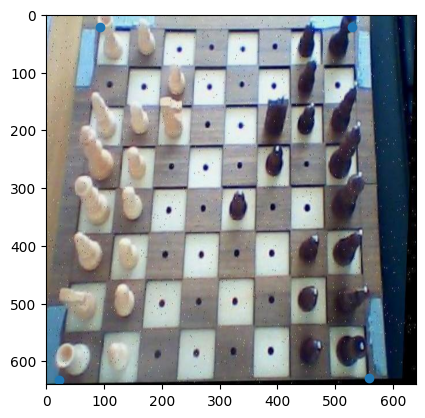

In [25]:
img, y = ds[100]

plt.imshow(img.permute(1,2,0));
plt.scatter(y["corners"][:,0], y["corners"][:,1])
y["fen"], y["image_path"], y["corners"]

In [8]:
count = 0

for lbl in ds.labels:
    if (lbl["corners"] == 0).all():
        print(lbl["image_path"])

        count += 1

count, len(ds)

/mnt/C/CNN_Dataset/Dataset/images/IMG_8264_JPG_jpg.rf.a39c70327224e7a2e301404c3c0f2003.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot447_png_jpg.rf.738966ab46faa6f46b761ea563788260.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot393_png_jpg.rf.8d6583e21b04044f04d0dfdf51c6fe05.jpg
/mnt/C/CNN_Dataset/Dataset/images/IMG_2716_jpg.rf.aa777760df11fcf0802fbe006d2b58e3.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot158_png_jpg.rf.9577673139b3b542982c158d42673dfc.jpg
/mnt/C/CNN_Dataset/Dataset/images/817I_png_jpg.rf.42310a05b0e9668b7a0cdce11e02d83a.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot394_png_jpg.rf.2ab2dc71af85c199dd8a9560dcad2b54.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot365_png_jpg.rf.2edecb2f2cd543b91e23a45d70ab410d.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot411_png_jpg.rf.6997612439310e274a9b9b5c0d53dd22.jpg
/mnt/C/CNN_Dataset/Dataset/images/IMG_2703_jpg.rf.9c38e64f6c0b51629afde74fa0435da6.jpg
/mnt/C/CNN_Dataset/Dataset/images/screenshot295_png_jpg.rf.3ce1920a7b541

(388, 7559)